In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
traffic_df = pd.read_csv("../dataset/processed/traffic_features.csv")
accident_df = pd.read_csv("../dataset/processed/accident_features.csv")

print("Traffic Shape :", traffic_df.shape)
print("Accident Shape:", accident_df.shape)

Traffic Shape : (952, 7)
Accident Shape: (49932, 30)


In [3]:
traffic_df.head()

,Date,Traffic Volume,Average Speed,Congestion Level,Travel Time Index,Road Capacity Utilization,Traffic_Exposure_Index
0,2022-01-01,35587.666667,40.646202,86.648310,1.449492,92.752653,0.462803
1,2022-01-02,27908.818182,40.920905,76.774305,1.365777,90.354193,0.349594
2,2022-01-03,26660.428571,36.213008,77.038268,1.421750,85.734298,0.331238
3,2022-01-04,29571.636364,39.386708,77.641283,1.365704,92.891541,0.374122
4,2022-01-05,32738.500000,38.791598,82.078308,1.364171,95.074434,0.420824


In [4]:
accident_df.head()

,DISTRICTNAME,UNITNAME,Crime_No,Year,RI,Noofvehicle_involved,Accident_Classification,Accident_Spot,Accident_Location,Accident_SubLocation,...,Weather,Accident_Road,Landmark_first,Distance_LandMark_First,Latitude,Longitude,Road_Condition_Score,Surface_Condition_Score,Surface_Type_Score,Road_Risk_Index
0,Bengaluru City,Adugodi Traffic PS,1.044320e+16,2016,1,1,Road Accidents,Cross roads,City/Town,At pedestrian Crossing,...,Clear,HOSUR LASKAR ROAD,GANESHA DARSHINI HOTEL,10MET,0.0,0.0,0,1,0.0,1.0
1,Bengaluru City,Adugodi Traffic PS,1.044320e+16,2016,1,3,Road Accidents,T Junction,City/Town,Near Bus stop,...,Fine,Sarjapura main road,Aishwarya junction,4km,0.0,0.0,0,0,0.0,0.0
2,Bengaluru City,Adugodi Traffic PS,1.044320e+16,2016,1,1,Road Accidents,Other,City/Town,Open area,...,Fine,HOSUR LASKAR ROAD,NEAR CAR SOUTH POLICE QTRS ADUGODI,500MTR,0.0,0.0,0,0,0.0,0.0
3,Bengaluru City,Adugodi Traffic PS,1.044320e+16,2016,1,1,Road Accidents,Other,City/Town,Near Bus stop,...,Fine,100 FEET RING ROAD KORAMANGALA,NEAR BDA COMPLEX KORAMANGALA,2KM,0.0,0.0,0,0,0.0,0.0
4,Bengaluru City,Adugodi Traffic PS,1.044320e+16,2016,1,2,Road Accidents,Other,City/Town,Open area,...,Fine,80feet road,1,1,0.0,0.0,0,0,0.0,0.0


In [5]:
print(traffic_df.isnull().sum())

print("\n------------------------\n")

print(accident_df.isnull().sum())

Date                         0
Traffic Volume               0
Average Speed                0
Congestion Level             0
Travel Time Index            0
Road Capacity Utilization    0
Traffic_Exposure_Index       0
dtype: int64

------------------------

DISTRICTNAME                 0
UNITNAME                     0
Crime_No                     0
Year                         0
RI                           0
Noofvehicle_involved         0
Accident_Classification      0
Accident_Spot                0
Accident_Location            0
Accident_SubLocation         0
Main_Cause                   0
Hit_Run                      0
Severity                     0
Collision_Type               0
Junction_Control             0
Road_Character               0
Road_Type                    0
Surface_Type                 0
Surface_Condition            0
Road_Condition               0
Weather                      0
Accident_Road                0
Landmark_first               0
Distance_LandMark_First      0

In [6]:
print(traffic_df.info())

print("\n---------------------------\n")

print(accident_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 952 entries, 0 to 951
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       952 non-null    str    
 1   Traffic Volume             952 non-null    float64
 2   Average Speed              952 non-null    float64
 3   Congestion Level           952 non-null    float64
 4   Travel Time Index          952 non-null    float64
 5   Road Capacity Utilization  952 non-null    float64
 6   Traffic_Exposure_Index     952 non-null    float64
dtypes: float64(6), str(1)
memory usage: 52.2 KB
None

---------------------------

<class 'pandas.DataFrame'>
RangeIndex: 49932 entries, 0 to 49931
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   DISTRICTNAME             49932 non-null  str    
 1   UNITNAME                 49932 non-null  str    
 2   

In [7]:
weather_score = {
    "Clear":0.05,
    "Fine":0.05,
    "Others":0.10,
    "Cloudy":0.12,
    "Fog / Mist":0.20,
    "Mist or Fog":0.20,
    "Light Rain":0.30,
    "Heavy Rain":0.40,
    "Dust Storm":0.45,
    "Flooding of Slipways/Rivulets":0.50,
    "Wind":0.15,
    "Strong Wind":0.20,
    "Very Hot":0.08,
    "Very Cold":0.10,
    "Snow":0.35,
    "Hail or Sleet":0.35,
    "Not Applicable":0.05
}

road_condition_score = {
    "Not Applicable":0.05,
    "No influence on accident":0.05,
    "Construction Work / Material":0.25,
    "Pot holed":0.45,
    "Drainage Ditch":0.35,
    "Engineering Defect of Road":0.50
}

surface_score = {
    "Dry":0.05,
    "Others":0.10,
    "Not Applicable":0.05,
    "Wet":0.30,
    "Muddy":0.35,
    "Ditch or Potholed":0.45,
    "Flooded":0.50
}

road_type_score = {
    "Expressway":0.35,
    "NH":0.30,
    "State Highway":0.28,
    "Major District Road":0.25,
    "Minor District Road":0.20,
    "Sub Arterial":0.20,
    "Arterial":0.18,
    "Residential Street":0.12,
    "Service Road":0.10,
    "One way":0.12,
    "Two way":0.18,
    "Mixed":0.18,
    "Others":0.15,
    "Forest Road":0.25,
    "Feeder Road":0.15,
    "Not Applicable":0.10
}

main_cause_score = {
    "Human Error":0.30,
    "Vehicle Defect":0.40,
    "Road Environment Defect":0.50,
    "Not Applicable":0.10
}

In [8]:
# ==========================================================
# PRIOR PROBABILITY
# ==========================================================

accident_df["Prior_Probability"] = (

    0.10

    + 0.25 * accident_df["Weather"].map(weather_score)

    + 0.25 * accident_df["Road_Condition"].map(road_condition_score)

    + 0.20 * accident_df["Surface_Condition"].map(surface_score)

    + 0.15 * accident_df["Road_Type"].map(road_type_score)

    + 0.15 * accident_df["Main_Cause"].map(main_cause_score)

)

accident_df["Prior_Probability"] = (
    accident_df["Prior_Probability"]
    .fillna(0.25)
    .clip(0.05, 0.95)
)

accident_df["Prior_Probability"].describe()

count    49932.000000
mean         0.222226
std          0.026289
min          0.165000
25%          0.202500
50%          0.222000
75%          0.250000
max          0.495500
Name: Prior_Probability, dtype: float64

In [9]:
# ==========================================================
# TRAFFIC EXPOSURE
# ==========================================================

traffic_exposure = traffic_df["Traffic_Exposure_Index"].mean()

print("Average Traffic Exposure:", traffic_exposure)

Average Traffic Exposure: 0.37057659087378825


In [10]:
# ==========================================================
# POSTERIOR PROBABILITY
# ==========================================================

likelihood = (

    0.45 * accident_df["Prior_Probability"]

    + 0.35 * traffic_exposure

    + 0.20

)

likelihood = likelihood.clip(0.05, 0.95)

posterior = (

    accident_df["Prior_Probability"] * likelihood

) / (

    accident_df["Prior_Probability"] * likelihood

    +

    (1 - accident_df["Prior_Probability"]) * (1 - likelihood)

)

accident_df["Posterior_Probability"] = posterior.clip(0.01, 0.99)

accident_df["Posterior_Probability"].describe()

count    49932.000000
mean         0.178050
std          0.030026
min          0.118104
25%          0.155760
50%          0.176895
75%          0.209020
max          0.548223
Name: Posterior_Probability, dtype: float64

In [11]:
# ==========================================================
# FINAL RISK SCORE
# ==========================================================

accident_df["Traffic_Exposure"] = traffic_exposure

accident_df["Final_Risk"] = (

    0.60 * accident_df["Posterior_Probability"]

    +

    0.40 * traffic_exposure

)

accident_df["Final_Risk"].describe()

count    49932.000000
mean         0.255060
std          0.018016
min          0.219093
25%          0.241687
50%          0.254368
75%          0.273643
max          0.477164
Name: Final_Risk, dtype: float64

In [15]:
# ==========================================================
# RISK LEVEL
# ==========================================================

accident_df["Risk_Level"] = pd.cut(

    accident_df["Final_Risk"],

    bins=[0,0.22,0.26,0.32,1],

    labels=[
        "Low",
        "Moderate",
        "High",
        "Critical"
    ]

)

accident_df["Risk_Level"].value_counts()

Risk_Level
Moderate    33454
High        15707
Critical      408
Low           363
Name: count, dtype: int64

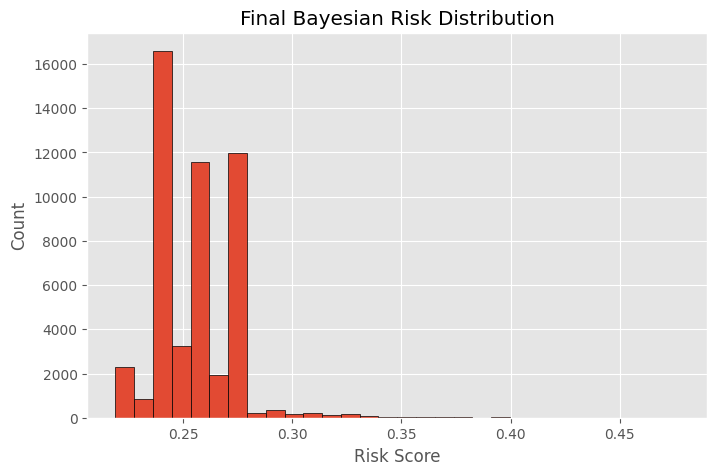

In [17]:
plt.figure(figsize=(8,5))

plt.hist(

    accident_df["Final_Risk"],

    bins=30,

    edgecolor="black"

)

plt.title("Final Bayesian Risk Distribution")

plt.xlabel("Risk Score")

plt.ylabel("Count")

plt.show()

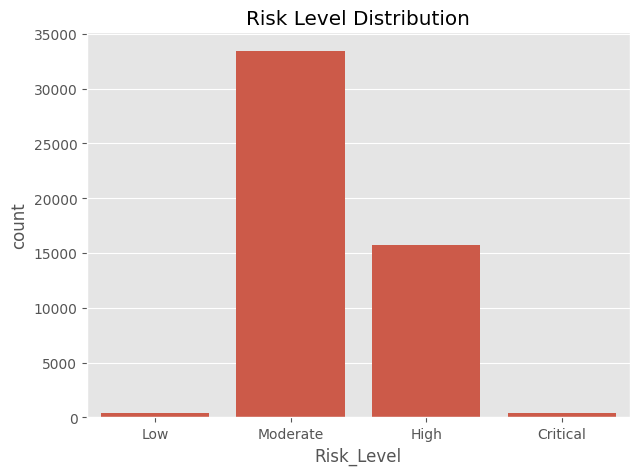

In [16]:
plt.figure(figsize=(7,5))

sns.countplot(

    x="Risk_Level",

    data=accident_df,

    order=["Low","Moderate","High","Critical"]

)

plt.title("Risk Level Distribution")

plt.show()

In [18]:
print(accident_df.shape)

(49932, 35)


In [19]:
print(traffic_df.shape)

(952, 7)


In [20]:
import os

print(os.listdir("../dataset"))

['accident', 'processed', 'traffic', 'weather']


In [21]:
accident_df.to_csv(
    "../dataset/processed/final_bayesian_risk.csv",
    index=False
)

print("Final Bayesian dataset exported successfully!")

Final Bayesian dataset exported successfully!


In [22]:
print(accident_df.columns.tolist())

['DISTRICTNAME', 'UNITNAME', 'Crime_No', 'Year', 'RI', 'Noofvehicle_involved', 'Accident_Classification', 'Accident_Spot', 'Accident_Location', 'Accident_SubLocation', 'Main_Cause', 'Hit_Run', 'Severity', 'Collision_Type', 'Junction_Control', 'Road_Character', 'Road_Type', 'Surface_Type', 'Surface_Condition', 'Road_Condition', 'Weather', 'Accident_Road', 'Landmark_first', 'Distance_LandMark_First', 'Latitude', 'Longitude', 'Road_Condition_Score', 'Surface_Condition_Score', 'Surface_Type_Score', 'Road_Risk_Index', 'Prior_Probability', 'Posterior_Probability', 'Traffic_Exposure', 'Final_Risk', 'Risk_Level']


In [23]:
print(accident_df["Severity"].unique())

<StringArray>
['Grievous Injury', 'Damage Only', 'Not Applicable', 'Simple Injury', 'Fatal']
Length: 5, dtype: str


# Bayesian Weight Optimization
Optimizing the weights of Posterior Probability, Road Risk Index, and Traffic Exposure using grid search.

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

results = []

# True labels
y_true = accident_df["Actual_Severity"].astype(int)

In [25]:
print(accident_df.columns)

Index(['DISTRICTNAME', 'UNITNAME', 'Crime_No', 'Year', 'RI',
       'Noofvehicle_involved', 'Accident_Classification', 'Accident_Spot',
       'Accident_Location', 'Accident_SubLocation', 'Main_Cause', 'Hit_Run',
       'Severity', 'Collision_Type', 'Junction_Control', 'Road_Character',
       'Road_Type', 'Surface_Type', 'Surface_Condition', 'Road_Condition',
       'Weather', 'Accident_Road', 'Landmark_first', 'Distance_LandMark_First',
       'Latitude', 'Longitude', 'Road_Condition_Score',
       'Surface_Condition_Score', 'Surface_Type_Score', 'Road_Risk_Index',
       'Prior_Probability', 'Posterior_Probability', 'Traffic_Exposure',
       'Final_Risk', 'Risk_Level'],
      dtype='str')


In [26]:
print(accident_df.columns.tolist())

['DISTRICTNAME', 'UNITNAME', 'Crime_No', 'Year', 'RI', 'Noofvehicle_involved', 'Accident_Classification', 'Accident_Spot', 'Accident_Location', 'Accident_SubLocation', 'Main_Cause', 'Hit_Run', 'Severity', 'Collision_Type', 'Junction_Control', 'Road_Character', 'Road_Type', 'Surface_Type', 'Surface_Condition', 'Road_Condition', 'Weather', 'Accident_Road', 'Landmark_first', 'Distance_LandMark_First', 'Latitude', 'Longitude', 'Road_Condition_Score', 'Surface_Condition_Score', 'Surface_Type_Score', 'Road_Risk_Index', 'Prior_Probability', 'Posterior_Probability', 'Traffic_Exposure', 'Final_Risk', 'Risk_Level']


In [27]:
# Create binary target

accident_df["Actual_Severity"] = accident_df["Severity"].isin(
    ["Fatal", "Grievous Injury"]
).astype(int)

print(accident_df["Actual_Severity"].value_counts())

Actual_Severity
1    29695
0    20237
Name: count, dtype: int64


In [29]:
results = []

for posterior_w in np.arange(0.20, 0.61, 0.05):

    for road_w in np.arange(0.10, 0.51, 0.05):

        traffic_w = 1 - posterior_w - road_w

        if traffic_w <= 0:
            continue

        # New Bayesian Risk Score
        risk = (
            posterior_w * accident_df["Posterior_Probability"] +
            road_w * accident_df["Road_Risk_Index"] +
            traffic_w * accident_df["Traffic_Exposure"]
        )

        # Threshold
        prediction = (risk >= 0.25).astype(int)

        results.append({

            "Posterior": posterior_w,
            "Road": road_w,
            "Traffic": traffic_w,

            "Accuracy": accuracy_score(y_true, prediction),
            "Precision": precision_score(
                y_true,
                prediction,
                zero_division=0
            ),
            "Recall": recall_score(
                y_true,
                prediction,
                zero_division=0
            ),
            "F1": f1_score(
                y_true,
                prediction,
                zero_division=0
            )
        })

results = pd.DataFrame(results)

In [ ]:
results = []

y_true = accident_df["Actual_Severity"]

for posterior_w in np.arange(0.20, 0.61, 0.05):

    for road_w in np.arange(0.10, 0.51, 0.05):

        traffic_w = 1 - posterior_w - road_w

        if traffic_w <= 0:
            continue

        risk = (
            posterior_w * accident_df["Posterior_Probability"] +
            road_w * accident_df["Road_Risk_Index"] +
            traffic_w * accident_df["Traffic_Exposure"]
        )

        for threshold in np.arange(0.20, 0.46, 0.01):

            pred = (risk >= threshold).astype(int)

            results.append({
                "Posterior": posterior_w,
                "Road": road_w,
                "Traffic": traffic_w,
                "Threshold": round(threshold, 2),
                "Accuracy": accuracy_score(y_true, pred),
                "Precision": precision_score(y_true, pred, zero_division=0),
                "Recall": recall_score(y_true, pred, zero_division=0),
                "F1": f1_score(y_true, pred, zero_division=0)
            })

results = pd.DataFrame(results)

In [30]:
results.sort_values(
    "Accuracy",
    ascending=False
).head(10)

,Posterior,Road,Traffic,Accuracy,Precision,Recall,F1
0,0.20,0.10,0.70,0.590683,0.594280,0.982489,0.740595
1,0.20,0.15,0.65,0.590683,0.594280,0.982489,0.740595
9,0.25,0.10,0.65,0.590683,0.594280,0.982489,0.740595
10,0.25,0.15,0.60,0.590683,0.594280,0.982489,0.740595
18,0.30,0.10,0.60,0.590683,0.594280,0.982489,0.740595
27,0.35,0.10,0.55,0.577285,0.591436,0.935343,0.724657
2,0.20,0.20,0.60,0.575743,0.591040,0.930359,0.722860
19,0.30,0.15,0.55,0.552612,0.587509,0.831554,0.688547
36,0.40,0.10,0.50,0.489826,0.569063,0.585620,0.577223
28,0.35,0.15,0.50,0.449411,0.560353,0.344401,0.426605


In [31]:
results.sort_values(
    "F1",
    ascending=False
).head(10)

,Posterior,Road,Traffic,Accuracy,Precision,Recall,F1
0,0.20,0.10,0.70,0.590683,0.594280,0.982489,0.740595
1,0.20,0.15,0.65,0.590683,0.594280,0.982489,0.740595
9,0.25,0.10,0.65,0.590683,0.594280,0.982489,0.740595
10,0.25,0.15,0.60,0.590683,0.594280,0.982489,0.740595
18,0.30,0.10,0.60,0.590683,0.594280,0.982489,0.740595
27,0.35,0.10,0.55,0.577285,0.591436,0.935343,0.724657
2,0.20,0.20,0.60,0.575743,0.591040,0.930359,0.722860
19,0.30,0.15,0.55,0.552612,0.587509,0.831554,0.688547
36,0.40,0.10,0.50,0.489826,0.569063,0.585620,0.577223
28,0.35,0.15,0.50,0.449411,0.560353,0.344401,0.426605


In [ ]:
results.sort_values("F1", ascending=False).head(20)